# **Lecture 10 Quiz : EM and GMMs**

### **The Scenario**
You are analysing a stream of data coming from a remote sensor network. The data (`X`) looks like a single blob of noise, but you suspect it is actually generated by two distinct sources (Source A and Source B) mixed together.

Since you don't have labels (Unsupervised Learning), you cannot use standard classification. You must implement a **Gaussian Mixture Model (GMM)** using the **Expectation-Maximization (EM)** algorithm to find the hidden parameters and separate the sources.

---

### **Part 1: Conceptual Stress-Tests**

**Question 1: The Hidden Assumption**

We often train regression models by minimizing the **Mean Squared Error (MSE)**:
$$ J(w) = \sum (y_i - w^T x_i)^2 $$

It can be mathematically shown that minimizing this MSE objective is identical to maximizing the Likelihood (MLE) of the data, but **only if** we make a specific assumption about the error term ($\epsilon$).

**What is that critical assumption?**
A) The error must be zero.

B) The error must follow a Uniform distribution.

C) The error must follow a Gaussian (Normal) distribution.

D) The error must be independent of the input $x$.

#### Answer:
- C) The error must follow a Gaussian (Normal) distribution.

explaination - the derivation of Least Squares from Maximum Likelihood relies on the assumption that the noise/residuals are normally distributed around the mean.

**Question 2: The Meaning of Gamma**

In the E-Step of the EM algorithm, we calculate the term $\gamma_k(x)$ (often called the "Responsibility"). 
Which of the following best describes what $\gamma_k(x)$ actually represents?

A) The prior probability that any point belongs to cluster $k$.

B) The posterior probability that a *specific* point $x$ belongs to cluster $k$, given we observed $x$.

C) The likelihood that cluster $k$ generated the entire dataset.

D) The variance of cluster $k$.

#### Answer:
- B) The posterior probability that a *specific* point $x$ belongs to cluster $k$, given we observed $x$.

explaination - calculated using Bayes theorem $\gamma_k(x) = P(z=k | x)$. It is the "responsibility" cluster $k$ takes for data point $x$ after seeing the data. 

### **Part 2: The Arithmetic of Belief**

**Question 3: The "Twilight" Fruit Problem**

**Scenario:** 
You are working in a warehouse with dim lighting. You have a crate containing **100 fruits**:
* **60 Mangoes** (50 are Green, 10 are Yellow)
* **40 Pears** (5 are Green, 35 are Yellow)

**The Vision Error:**
Due to the bad lighting, your vision is unreliable:
* If a fruit is **Green**, you mistake it for **Yellow** **20%** of the time ($P(See=Y | Real=G) = 0.2$).
* If a fruit is **Yellow**, you **never** mistake it ($P(See=Y | Real=Y) = 1.0$).

**The Test:**
You pick a fruit from the crate. You look at it, and you **see YELLOW**.

**Task:**
Calculate the probability that the fruit you are holding is actually a **MANGO**.
$$ P(\text{Real}=\text{Mango} | \text{See}=\text{Yellow}) $$

*Show your calculation steps below using Bayes Rule.*

Given: Priors:$P(\text{Mango}) = 60/100 = 0.6$ $P(\text{Pear}) = 40/100 = 0.4$  
Distributions within fruits: Mangoes: 50 Green, 10 Yellow. 
$\rightarrow P(\text{Green}|\text{Mango}) = 50/60$ , $P(\text{Yellow}_{\text{real}}|\text{Mango}) = 10/60$.Pears: 5 Green, 35 Yellow. 
$\rightarrow P(\text{Green}|\text{Pear}) = 5/40$, $P(\text{Yellow}_{\text{real}}|\text{Pear}) = 35/40$ .
Vision Error Model:$P(\text{See Yellow} | \text{Real Green}) = 0.2$ 
$P(\text{See Yellow} | \text{Real Yellow}) = 1.0$

Step 1: Calculate the likelihood of seeing Yellow given it is a Mango.$$\begin{aligned} P(\text{See Y} | \text{Mango}) &= P(\text{See Y} | \text{Real G})P(\text{Real G}|\text{M}) + P(\text{See Y} | \text{Real Y})P(\text{Real Y}|\text{M}) \\ &= 0.2 \times \frac{50}{60} + 1.0 \times \frac{10}{60} \\ &= \frac{1}{5} \times \frac{5}{6} + \frac{1}{6} \\ &= \frac{1}{6} + \frac{1}{6} = \frac{2}{6} = \frac{1}{3} \approx 0.333 \end{aligned}$$Step 2: Calculate the likelihood of seeing Yellow given it is a Pear.$$\begin{aligned} P(\text{See Y} | \text{Pear}) &= P(\text{See Y} | \text{Real G})P(\text{Real G}|\text{P}) + P(\text{See Y} | \text{Real Y})P(\text{Real Y}|\text{P}) \\ &= 0.2 \times \frac{5}{40} + 1.0 \times \frac{35}{40} \\ &= \frac{1}{5} \times \frac{1}{8} + \frac{7}{8} \\ &= \frac{1}{40} + \frac{35}{40} = \frac{36}{40} = \frac{9}{10} = 0.9 \end{aligned}$$Step 3: Calculate Total Probability of Seeing Yellow (Evidence).$$\begin{aligned} P(\text{See Y}) &= P(\text{See Y} | \text{Mango})P(\text{Mango}) + P(\text{See Y} | \text{Pear})P(\text{Pear}) \\ &= (\frac{1}{3} \times 0.6) + (0.9 \times 0.4) \\ &= 0.2 + 0.36 = 0.56 \end{aligned}$$Step 4: Apply Bayes Rule.$$P(\text{Mango} | \text{See Y}) = \frac{P(\text{See Y} | \text{Mango}) P(\text{Mango})}{P(\text{See Y})} = \frac{0.2}{0.56} = \frac{20}{56} = \frac{5}{14} \approx 0.357$$Solution: $5/14$ or approx $35.7\%$


### **Part 3: Coding Challenge — Writing the EM Algorithm**

In this section, you will implement the core logic of a Gaussian Mixture Model.
We have generated 1D data from two hidden Gaussian distributions. Your job is to separate them.

**Formulas for Reference:**

**1. E-Step (Responsibilities):**
$$ \gamma_j(x_i) = \frac{\pi_j \mathcal{N}(x_i | \mu_j, \sigma_j^2)}{\sum_{k=1}^K \pi_k \mathcal{N}(x_i | \mu_k, \sigma_k^2)} $$

**2. M-Step (Parameter Updates):**
$$ N_j = \sum_{i=1}^N \gamma_j(x_i) $$

$$ \mu_j^{new} = \frac{1}{N_j} \sum_{i=1}^N \gamma_j(x_i) x_i $$

$$ \sigma_j^{new} = \sqrt{ \frac{1}{N_j} \sum_{i=1}^N \gamma_j(x_i) (x_i - \mu_j^{new})^2 } $$

$$ \pi_j^{new} = \frac{N_j}{N} $$

Here Sigma is the standard deviation, not the variance.

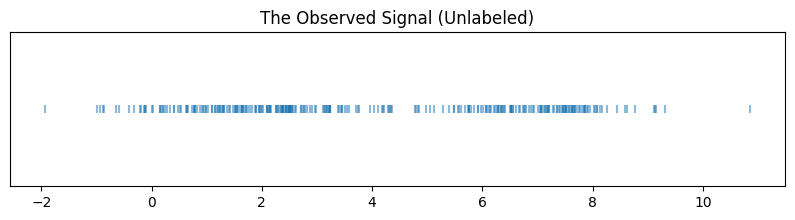

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Generate Synthetic Data (Do not modify) ---
np.random.seed(42)

# True Parameters (Unknown to you)
mu_true = [2, 7]
sigma_true = [1.5, 1.0]
pi_true = [0.6, 0.4]  # 60% data from cluster 0, 40% from cluster 1

n_samples = 300
# Generate mixture data
X = np.concatenate([
    np.random.normal(mu_true[0], sigma_true[0], int(n_samples * pi_true[0])),
    np.random.normal(mu_true[1], sigma_true[1], int(n_samples * pi_true[1]))
])

# Shuffle data so we don't know the order
np.random.shuffle(X)

# Visualization of the Raw "Noisy" Data
plt.figure(figsize=(10, 2))
plt.title("The Observed Signal (Unlabeled)")
plt.scatter(X, np.zeros_like(X), alpha=0.5, marker='|')
plt.yticks([])
plt.show()

In [2]:
# --- Initialization (Random Guess) ---
k = 2  # Number of clusters
mu = np.array([0.0, 10.0])  # Initial guess for means
sigma = np.array([1.0, 1.0]) # Initial guess for std dev
pi = np.array([0.5, 0.5])   # Initial guess for priors

n_iters = 20
log_likelihoods = []

print(f"Initial Guesses: mu={mu}, sigma={sigma}")

Initial Guesses: mu=[ 0. 10.], sigma=[1. 1.]


In [3]:
def e_step(X, mu, sigma, pi):
    """
    Computes the responsibilities (gamma).
    
    Returns:
        gamma: (N, k) array where gamma[i, j] is prob that point i belongs to cluster j
    """
    N = X.shape[0]
    k = len(mu)
    gamma = np.zeros((N, k))
    
    # -----------------------------------------------------
    # TODO: Implement the Gamma formula
    # Division by zero can be an issue if sigma is too small, so add a small epsilon to the denominator if needed.
    # Hint: Numerator = pi_k * Normal(x | mu_k, sigma_k)
    # Hint: Denominator = Sum over all j (Numerator_j)
    # Use norm.pdf(X, loc=..., scale=...) for the Gaussian prob
    
    for j in range(k):
        gamma[:, j] = pi[j] * norm.pdf(X, loc=mu[j], scale=sigma[j])
    
    sum_gamma = np.sum(gamma, axis=1, keepdims=True)

    gamma = gamma / (sum_gamma + 1e-10)
    
    # -----------------------------------------------------
    return gamma

In [4]:
def m_step(X, gamma):
    """
    Updates parameters based on responsibilities.
    """
    N = X.shape[0]
    k = gamma.shape[1]
    
    # -----------------------------------------------------
    # TODO: Implement parameter updates
    # Hint: Effective N_k = sum(gamma[:, k])

    N_j = np.sum(gamma, axis=0)
    
    # new_mu = ... (Weighted average of X)
    # new_pi = ... (N_k / N)
    # new_sigma = ... (Weighted variance or std dev)
    # Remember to take the square root for sigma since we want std dev, not variance.
    
    pi_new = N_j / N
    
    # 3. Update mu (Means)
    # Weighted sum of X, where weights are gamma
    # We reshape X to (N, 1) to broadcast against gamma (N, k)
    mu_new = np.sum(gamma * X[:, np.newaxis], axis=0) / N_j
    
    # 4. Update sigma (Standard Deviations)
    sigma_new = np.zeros(k)
    for j in range(k):
        # Difference between data and NEW mean
        diff = X - mu_new[j]
        # Weighted squared difference
        weighted_sq_diff = gamma[:, j] * (diff ** 2)
        # Variance
        variance = np.sum(weighted_sq_diff) / N_j[j]
        # Standard Deviation
        sigma_new[j] = np.sqrt(variance)
    
    return mu_new, sigma_new, pi_new

--- Converged Parameters ---
Est Means: [1.89552221 6.96141604]
True Means: [2, 7]
Est Stds:  [1.35168365 1.06792885]
True Stds: [1.5, 1.0]


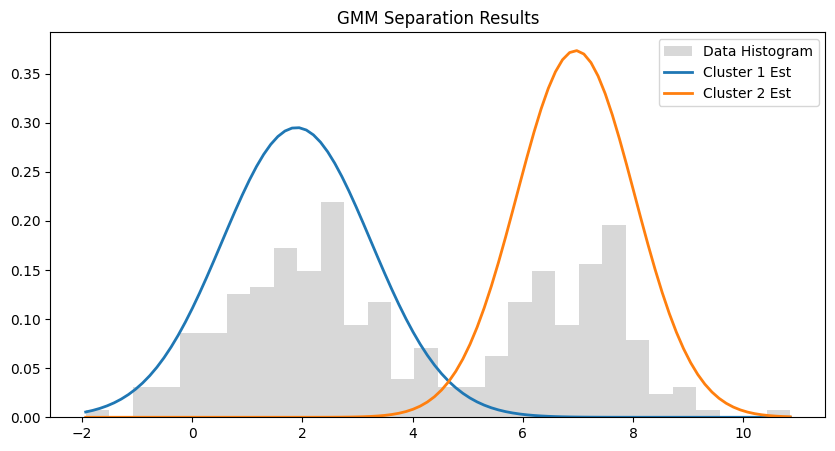

In [5]:
# --- Run the Loop ---
try:
    for i in range(n_iters):
        # 1. E-Step
        gamma = e_step(X, mu, sigma, pi)
        
        # 2. M-Step
        mu, sigma, pi = m_step(X, gamma)
        
        # (Optional) Log Likelihood for tracking convergence
        # ll = np.sum(
        #     np.log(
        #         pi[0] * norm.pdf(X, mu[0], sigma[0]) +
        #         pi[1] * norm.pdf(X, mu[1], sigma[1])
        #     ))
        # log_likelihoods.append(ll)

    print("--- Converged Parameters ---")
    print(f"Est Means: {mu}")
    print(f"True Means: {mu_true}")
    print(f"Est Stds:  {sigma}")
    print(f"True Stds: {sigma_true}")
    
    # Visualize Final Separation
    plt.figure(figsize=(10, 5))
    plt.hist(X, bins=30, density=True, alpha=0.3, color='gray', label='Data Histogram')
    x_axis = np.linspace(min(X), max(X), 100)
    plt.plot(x_axis, norm.pdf(x_axis, mu[0], sigma[0]), label='Cluster 1 Est', linewidth=2)
    plt.plot(x_axis, norm.pdf(x_axis, mu[1], sigma[1]), label='Cluster 2 Est', linewidth=2)
    plt.title("GMM Separation Results")
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}\nDid you implement the TODO blocks?")